Dataset OxfordIIITPet
    Number of datapoints: 3680
    Root location: ./data


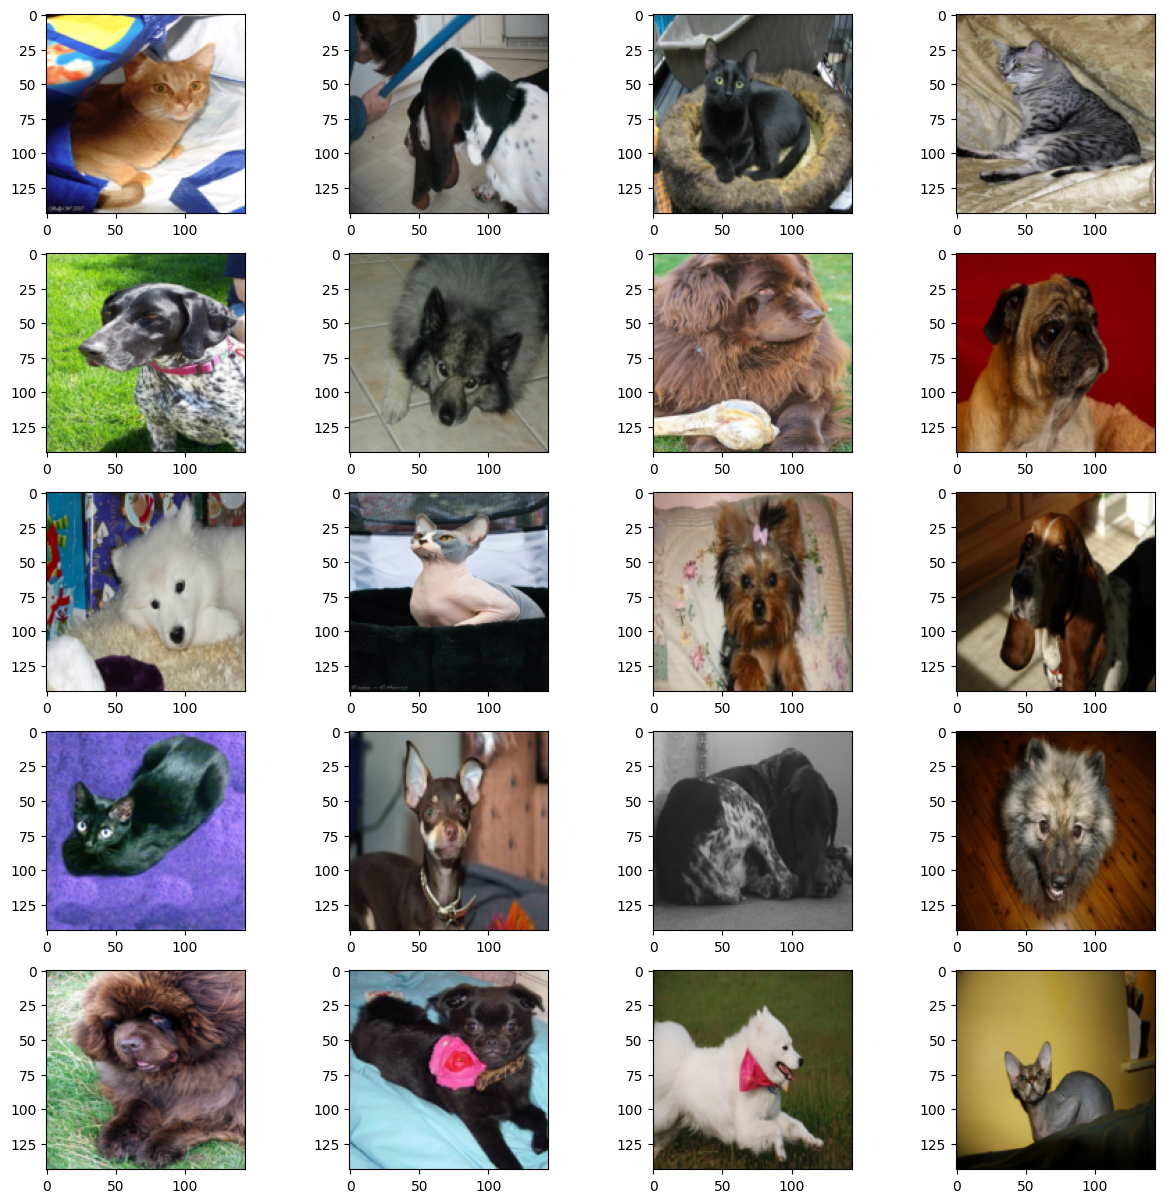

In [2]:
from torch._export.passes import insert_custom_op_guards
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.transforms import Resize, ToTensor
from torchvision.transforms.functional import to_pil_image
from torchvision.datasets import OxfordIIITPet

# Optional but highly recommended for ViT implementation (patchification, etc.)
# If you don't have it installed, you can use pip install einops
try:
    from einops import rearrange, repeat
    from einops.layers.torch import Rearrange
except ImportError:
    print("Warning: einops is not installed. It is highly recommended for building ViT from scratch.")
to_tensor = [Resize((144,144)), ToTensor()]

class Compose(object): 
    def __init__(self, transforms):
        self.transforms = transforms
    def __call__(self, image, target): 
        for t in self.transforms:
            image = t(image)
        return image, target
def show_images(images, num_samples = 20, cols = 4): 
    plt.figure(figsize=(15,15))
    idx = int(len(dataset) / num_samples)
    print(images)
    for i, img in enumerate(images): 
        if i%idx == 0: 
            plt.subplot(int(num_samples / cols), cols, int(i/idx)+1) 
            plt.imshow(to_pil_image(img[0]))
dataset = OxfordIIITPet(root = "./data", download=True, transforms=Compose(to_tensor))
show_images(dataset)

In [4]:
from einops.layers.torch import Rearrange
from torch import  nn , Tensor
class PatchEmbedding(nn.Module): 
    def __init__(self, in_channels= 3, patch_size =8 , emb_size = 128): 
        self.patch_size = patch_size
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_size, p2 = patch_size),
            nn.Linear( patch_size * patch_size* in_channels,emb_size)
        )
    def forward(self, x: Tensor): 
        x = self.projection
        return x

sample_datapoint = torch.unsqueeze(dataset[0][0], 0)
print("Initial shape:", sample_datapoint.shape)
emb = PatchEmbedding()(sample_datapoint)
print("Final shape:", emb.shape)


Initial shape: torch.Size([1, 3, 144, 144])


AttributeError: 'Sequential' object has no attribute 'shape'

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, idx, pos, d=128):
        
